In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt 
import tldextract

In [2]:
def mergeIDs(row):
    combined_list = []
    for entry in row:
        if isinstance(entry, list):
            combined_list.extend(entry)
    return list(set(combined_list)) if combined_list else None

In [3]:
def readDataframe(csv_file):
    df = pd.read_csv(csv_file)
    try:
        df.drop(columns=['Unnamed: 0'],inplace=True)
    except:
        pass

    for column in df.columns:
        def safe_literal_eval(x):
            if isinstance(x, str) and pd.notna(x):
                try:
                    return ast.literal_eval(x) if pd.notna(x) else x
                except (ValueError, SyntaxError):
                    return x  # Return empty list for problematic entries
            return x  # Return empty list for None or non-string entries
        df[column] = df[column].apply(safe_literal_eval)
    return df


def extract_domain(url):
    ext = tldextract.extract(url)
    return f"{ext.domain}.{ext.suffix}" if ext.suffix else ext.domain

In [16]:
# Specify paths to the processed configuration dataframe generated using processSnapshots.py
HOSPITAL_CONFIGURATION_DF_PATH = '../Configurations/health-configurations.csv' 
TOP_10K_CONFIGURATION_DF_PATH = '../Configurations/top-10k-configurations.csv'

HOSPITAL_PIXEL_HISTORY_PATH = '../Pixel History/final_pixel_health_hospitals.csv'
TOP_10K_PIXEL_HISTORY_PATH = '../Pixel History/final_pixel_history_top10k.csv'

health_websites_configurations = readDataframe(HOSPITAL_CONFIGURATION_DF_PATH)
top10k_websites_configurations = readDataframe(TOP_10K_CONFIGURATION_DF_PATH)
health_websites_configurations['timestamp'] = pd.to_datetime(health_websites_configurations['timestamp'])
top10k_websites_configurations['timestamp'] = pd.to_datetime(top10k_websites_configurations['timestamp'])

health_pixel_presence = readDataframe(HOSPITAL_PIXEL_HISTORY_PATH)
top10k_pixel_presence = readDataframe(TOP_10K_PIXEL_HISTORY_PATH)

/tmp/ipykernel_492603/1329448572.py:2: DtypeWarning: Columns (3,99) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_492603/1329448572.py:2: DtypeWarning: Columns (2,3,4,5,6,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal


In [6]:
top10k_pixel_presence['Combined'] = top10k_pixel_presence.apply(mergeIDs,axis=1)

/tmp/ipykernel_492603/2766956265.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  top10k_pixel_presence['Combined'] = top10k_pixel_presence.apply(mergeIDs,axis=1)


In [7]:
len(top10k_pixel_presence[top10k_pixel_presence['Combined'].apply(lambda x: True if isinstance(x, list) and len(x) > 0 else False)]['website'].unique())

3486

In [8]:
print("Configuration Files for websites: ",len(set(top10k_websites_configurations['website'])), " | Total Websites present on wayback",len(set(top10k_pixel_presence['website'])))

Configuration Files for websites:  2771  | Total Websites present on wayback 8847


### Done Loading. Time to analyze

### Top10k Presence


In [9]:
# Group columns by year excluding 'id' and 'website'
def group_by_year(df):
    year_columns = {}

    # Get all columns except for the first
    cols_to_process = df.columns[1:]

    # Iterate over column names
    for col in cols_to_process:
        year = col[:4]  # Extract the year part
        if year not in year_columns:
            year_columns[year] = []
        year_columns[year].append(col)

    # Combine values for each year
    result = {}
    for year, cols in year_columns.items():
        result[year] = df[cols].apply(
            lambda row: [x for val in row if isinstance(val, list) for x in val],
            axis=1
        )
    return pd.DataFrame(result)


yearly_df = group_by_year(top10k_pixel_presence)
final_df = pd.concat([top10k_pixel_presence[['website']], yearly_df], axis=1)

years = ["2024","2023","2022","2021","2020","2019","2018","2017"]
for yr in years:
    final_df[yr] = final_df[yr].apply(lambda x: x if isinstance(x, list) else [])

grouped = (
    final_df
    .groupby('website')[years]
    .agg(lambda lists: sum(lists, []))
    .reset_index()
)
display(grouped)

,website,2024,2023,2022,2021,2020,2019,2018,2017
0,0123movie.net,[],[],[],[],[],[],[],[]
1,037hdmovie.com,[],[],[],[],[],[],[],[]
2,10086.cn,[],[],[],[],[],[],[],[]
3,100panel.com,[],[],[],[],[],[],[],[]
4,101.ru,[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...
8842,zuimeitianqi.com,[],[],[],[],[],[],[],[]
8843,zuora.com,"[660045520856070, 833335806849806, 66004552085...","[660045520856070, 833335806849806, 66004552085...","[660045520856070, 833335806849806, 66004552085...","[660045520856070, 833335806849806, 66004552085...","[660045520856070, 833335806849806, 66004552085...","[660045520856070, 660045520856070]","[660045520856070, 660045520856070]",[660045520856070]
8844,zus.pl,[],[],[],[],[],[],[],[]
8845,zynga.com,[],[],[],[],[],[],[],[]


In [10]:
top10k_websites_configurations['timestamp'] = pd.to_datetime(top10k_websites_configurations['timestamp'])
top10k_websites_configurations['year'] = top10k_websites_configurations['timestamp'].dt.year

/tmp/ipykernel_492603/131262113.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pixel_presence_count = grouped.iloc[:, 1:].applymap(lambda x: isinstance(x, list) and len(x) > 0).sum()


<Axes: title={'center': 'Number of Top-10K Websites with a Pixel'}>

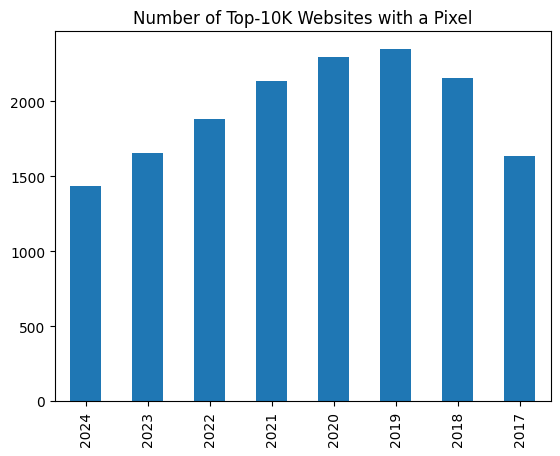

In [11]:
pixel_presence_count = grouped.iloc[:, 1:].applymap(lambda x: isinstance(x, list) and len(x) > 0).sum()
pixel_presence_count.plot(kind='bar', title='Number of Top-10K Websites with a Pixel')

In [12]:
top10k_websites_configurations['timestamp'] = pd.to_datetime(top10k_websites_configurations['timestamp'])
top10k_websites_configurations['year'] = top10k_websites_configurations['timestamp'].dt.year

pixel_count = {}

for year in years:
    config_websites = top10k_websites_configurations[top10k_websites_configurations['year']==int(year)]['website'].unique()
    pixel_websites = grouped[grouped[year].apply(lambda x: True if isinstance(x,list) and len(x)>0 else False)]['website'].values

    total_websites = set(list(config_websites) + list(pixel_websites))
    pixel_count[year] = len(total_websites)
    
pixel_count

{'2024': 1445,
 '2023': 1676,
 '2022': 1902,
 '2021': 2146,
 '2020': 2315,
 '2019': 2364,
 '2018': 2171,
 '2017': 1658}

### Top 10K Configurations Presence

In [13]:
unique_websites_per_year = top10k_websites_configurations.groupby('year')['website'].nunique()
unique_websites_per_year

year
2017    1066
2018    1777
2019    1982
2020    1920
2021    1075
2022    1030
2023     972
2024     707
2025      20
Name: website, dtype: int64

,website,2024,2023,2022,2021,2020,2019,2018,2017
0,0123movie.net,[],[],[],[],[],[],[],[]
1,037hdmovie.com,[],[],[],[],[],[],[],[]
2,10086.cn,[],[],[],[],[],[],[],[]
3,100panel.com,[],[],[],[],[],[],[],[]
4,101.ru,[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...
8842,zuimeitianqi.com,[],[],[],[],[],[],[],[]
8843,zuora.com,"[660045520856070, 833335806849806, 66004552085...","[660045520856070, 833335806849806, 66004552085...","[660045520856070, 833335806849806, 66004552085...","[660045520856070, 833335806849806, 66004552085...","[660045520856070, 833335806849806, 66004552085...","[660045520856070, 660045520856070]","[660045520856070, 660045520856070]",[660045520856070]
8844,zus.pl,[],[],[],[],[],[],[],[]
8845,zynga.com,[],[],[],[],[],[],[],[]


[1658, 2171, 2364, 2315, 2146, 1902, 1676, 1445]

[1066, 1777, 1982, 1920, 1075, 1030, 972, 707]

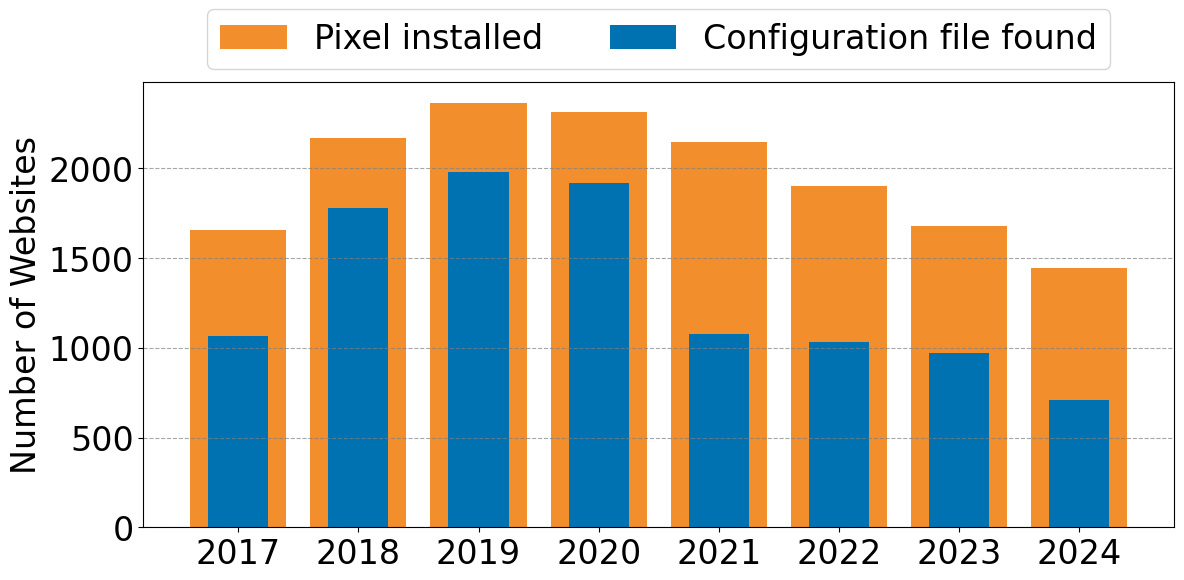

In [14]:

# Group columns by year excluding 'id' and 'website'
def group_by_year(df):
    year_columns = {}

    # Get all columns except for the first
    cols_to_process = df.columns[1:]

    # Iterate over column names
    for col in cols_to_process:
        year = col[:4]  # Extract the year part
        if year not in year_columns:
            year_columns[year] = []
        year_columns[year].append(col)

    # Combine values for each year
    result = {}
    for year, cols in year_columns.items():
        result[year] = df[cols].apply(
            lambda row: [x for val in row if isinstance(val, list) for x in val],
            axis=1
        )
    return pd.DataFrame(result)


yearly_df = group_by_year(top10k_pixel_presence)
final_df = pd.concat([top10k_pixel_presence[['website']], yearly_df], axis=1)

years = ["2024","2023","2022","2021","2020","2019","2018","2017"]
for yr in years:
    final_df[yr] = final_df[yr].apply(lambda x: x if isinstance(x, list) else [])

grouped = (
    final_df
    .groupby('website')[years]
    .agg(lambda lists: sum(lists, []))
    .reset_index()
)
display(grouped)

top10k_websites_configurations['timestamp'] = pd.to_datetime(top10k_websites_configurations['timestamp'])
top10k_websites_configurations['year'] = top10k_websites_configurations['timestamp'].dt.year

pixel_count = {}

for year in years:
    config_websites = top10k_websites_configurations[top10k_websites_configurations['year']==int(year)]['website'].unique()
    pixel_websites = grouped[grouped[year].apply(lambda x: True if isinstance(x,list) and len(x)>0 else False)]['website'].values

    total_websites = set(list(config_websites) + list(pixel_websites))
    pixel_count[year] = len(total_websites)
    
pixel_count
# Re-import libraries after code execution environment reset
import matplotlib.pyplot as plt
import pandas as pd

# Exclude 2025
# pixel_presence = pixel_presence_count[pixel_presence_count.index < 2025]
pixel_presence = pixel_count
unique_websites_per_year = top10k_websites_configurations.groupby('year')['website'].nunique()
unique_websites_per_year = unique_websites_per_year[unique_websites_per_year.index < 2025]

# Align years
all_years = ["2017","2018","2019","2020","2021","2022","2023","2024"]
pixel_values = [pixel_presence.get(year, 0) for year in all_years]
all_years = list(range(2017, 2025))
unique_values = [unique_websites_per_year.get(year, 0) for year in all_years]

display(pixel_values,unique_values)

# Plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 24
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams['legend.fontsize'] = 24

fig, ax = plt.subplots()
ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)

# Main bars: total websites
ax.bar(all_years, pixel_values, color='#F28E2B', label='Pixel installed')
ax.bar(all_years, unique_values,width=0.5, color='#0072B2', label='Configuration file found')

# Overlay bars: with pixel

ax.set_ylabel('Number of Websites')
ax.set_xticks(all_years)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)

plt.tight_layout()
plt.savefig("pixel_top10K_count.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()


## Hospital Presence

In [17]:
print("Configuration Files for websites: ",len(set(health_websites_configurations['website'])), " | Total Websites present on wayback",len(set(health_pixel_presence['website'])))

Configuration Files for websites:  1174  | Total Websites present on wayback 18302


In [18]:
health_pixel_presence['Combined'] = health_pixel_presence.apply(mergeIDs,axis=1) 

len(health_pixel_presence[health_pixel_presence['Combined'].apply(lambda x: True if isinstance(x, list) and len(x) > 0 else False)]['website'].unique())

/tmp/ipykernel_492603/3866797933.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  health_pixel_presence['Combined'] = health_pixel_presence.apply(mergeIDs,axis=1)


3375

In [15]:
# Group columns by year excluding 'id' and 'website'
def group_by_year(df):
    year_columns = {}

    # Get all columns except for the first
    cols_to_process = df.columns[1:]

    # Iterate over column names
    for col in cols_to_process:
        year = col[:4]  # Extract the year part
        if year not in year_columns:
            year_columns[year] = []
        year_columns[year].append(col)

    # Combine values for each year
    result = {}
    for year, cols in year_columns.items():
        result[year] = df[cols].apply(
            lambda row: [x for val in row if isinstance(val, list) for x in val] if not row.isna().all() else None,
            axis=1
        )
    return pd.DataFrame(result)


yearly_df = group_by_year(health_pixel_presence)
final_df = pd.concat([health_pixel_presence'website']], yearly_df], axis=1)

years = ["2024","2023","2022","2021","2020","2019","2018","2017"]
for yr in years:
    final_df[yr] = final_df[yr].apply(lambda x: x if isinstance(x, list) else [])

grouped_hospitals = (
    final_df
    .groupby('website')[years]
    .agg(lambda lists: sum(lists, []))
    .reset_index()
)
display(grouped_hospitals)

,website,2024,2023,2022,2021,2020,2019,2018,2017
0,1stchoice-ar.org,[],[],[],[],[],[],[],[]
1,1stchoiceicc.com,[],"[191430933086664, 191430933086664]",[],[],[],[],[],[]
2,219health.org,[],[],[],[],[],[],[],[]
3,21stcenturyrehab.com,"[410008033174768, 410008033174768]","[410008033174768, 410008033174768]","[410008033174768, 410008033174768]","[410008033174768, 410008033174768]",[410008033174768],[],[],[]
4,24hrer.com,[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...
18297,zarrowpointe.org,[],[],[],[],[],[],[],[]
18298,zearinghealthcarecenter.com,[],[],[],[],[],[],[],[]
18299,zhs.sfhs.org,[],[],[],[],[],[],[],[]
18300,zoomphysicaltherapy.com,[907106021047603],[],[],[],[],[],[],[]


In [18]:
health_websites_configurations['timestamp'] = pd.to_datetime(health_websites_configurations['timestamp'])
health_websites_configurations['year'] = health_websites_configurations['timestamp'].dt.year


year_cols = [c for c in grouped_hospitals.columns if c != 'website']

grouped_hospitals['non_empty_years'] = (
    grouped_hospitals[year_cols]
      .apply(lambda row: [year for year, lst in row.items() if lst], axis=1)
)


grouped_hospitals['non_empty_years'] = grouped_hospitals['non_empty_years'].apply(lambda lst: [int(y) for y in lst])
year_map = {
    site: set(years)
    for site, years in zip(grouped_hospitals['website'], grouped_hospitals['non_empty_years'])
}
year_map
df2_filtered = health_websites_configurations[health_websites_configurations.apply(
    lambda row: row['year'] in year_map.get(row['website'], set()),
    axis=1
)].reset_index(drop=True)


df2_filtered

,plugin_name,opt_in_info,config_set_info,fbq_set_info,timestamp,website,pixel_id,year
0,[],[],[],[],2017-04-21 13:47:51,www.manta.com,909192682497415,2017
1,[],[],[],[],2017-04-23 14:22:32,wakehealth.edu,204131909946380,2017
2,[],[],[],[],2017-04-24 23:25:33,www.indeed.com,579216298929618,2017
3,[],[],[],[],2017-04-25 21:33:43,houstonmethodist.org,244102129294472,2017
4,[],[],[],[],2017-04-27 03:49:56,mhs.net,1397289793845022,2017
...,...,...,...,...,...,...,...,...
12531,"[inferredevents, identity, iwlbootstrapper, co...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': None, 'di...",[],2024-12-13 12:25:55,capitalhealth.com,1401480206566122,2024
12532,"[iwlbootstrapper, cookie, automaticmatchingfor...","[(iwlbootstrapper, true), (firstpartycookies, ...","[(cookie, {'fbcParamsConfig': {'params': [{'pr...",[],2024-12-20 18:42:11,uabmedicine.org,575289237531506,2024
12533,"[iwlbootstrapper, iwlparameters, cookie, autom...","[(iwlbootstrapper, true), (iwlparameters, true...","[(cookie, {'fbcParamsConfig': {'params': [{'pr...","[(iwlextractors, [{'domain_uri': 'https://web....",2024-12-20 19:07:23,uabmedicine.org,169509440322063,2024
12534,"[iwlbootstrapper, iwlparameters, cookie, autom...","[(iwlbootstrapper, true), (iwlparameters, true...","[(cookie, {'fbcParamsConfig': {'params': [{'pr...","[(iwlextractors, []), (estrules, [{'condition'...",2024-12-21 00:24:24,lionsgateccrc.org,279234506668860,2024


In [29]:
df2_filtered.to_csv('filtered_hospital_configurations.csv', index=False)

In [21]:
health_websites_configurations['timestamp'] = pd.to_datetime(health_websites_configurations['timestamp'])
health_websites_configurations['year'] = health_websites_configurations['timestamp'].dt.year

hospital_pixel_count = {}

year_websites_lengths = []

for year in years:
    print(year)
    config_websites = health_websites_configurations[health_websites_configurations['year']==int(year)]['website'].unique()
    pixel_websites = grouped_hospitals[grouped_hospitals[year].apply(lambda x: True if isinstance(x,list) and len(x)>0 else False)]['website'].values

    year_websites_lengths.append(len(config_websites))

    total_websites = set(list(config_websites) + list(pixel_websites))
    hospital_pixel_count[year] = len(total_websites)
    
hospital_pixel_count

2024
2023
2022
2021
2020
2019
2018
2017


{'2024': 1267,
 '2023': 1626,
 '2022': 2121,
 '2021': 2206,
 '2020': 1895,
 '2019': 1613,
 '2018': 1114,
 '2017': 622}

In [33]:
pixel_id_counts = []
for year in years:
    config_ids = top10k_websites_configurations[top10k_websites_configurations['year']==int(year)]['pixel_id'].unique()
    pixel_id_counts.append(len(config_ids))


In [34]:
np.mean(pixel_id_counts)

1587.375

/tmp/ipykernel_10597/2556991586.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  hospital_pixel_presence = grouped_hospitals.iloc[:, 1:].applymap(lambda x: isinstance(x, list) and len(x) > 0).sum()


<Axes: title={'center': 'Number of Websites with a Pixel'}>

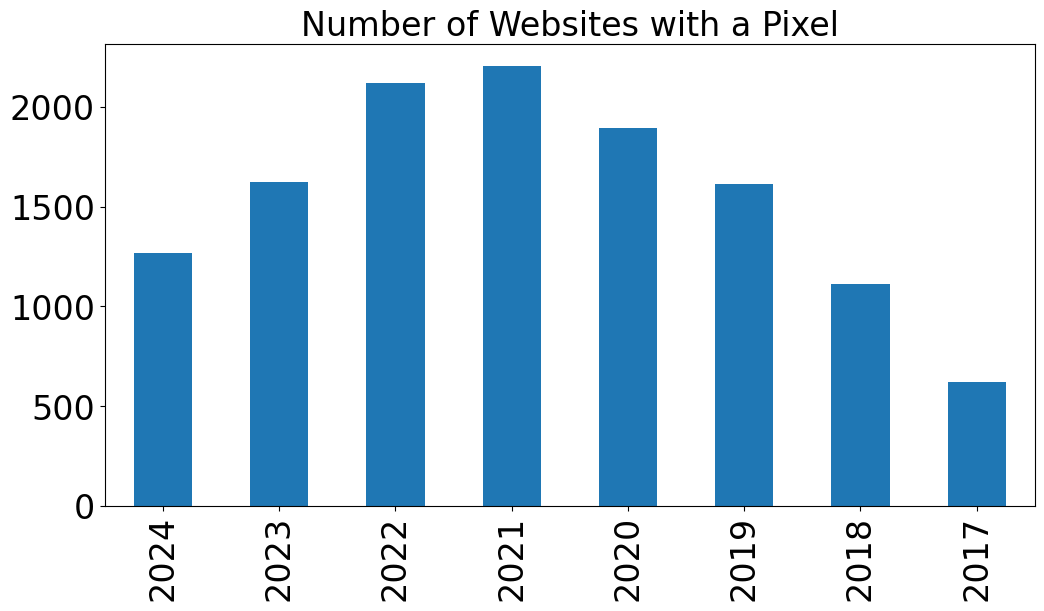

In [35]:
health_pixel_presence = grouped_hospitals.iloc[:, 1:].applymap(lambda x: isinstance(x, list) and len(x) > 0).sum()
health_pixel_presence.plot(kind='bar', title='Number of Websites with a Pixel')


In [19]:
health_websites_configurations['timestamp'] = pd.to_datetime(health_websites_configurations['timestamp'])
health_websites_configurations['year'] = health_websites_configurations['timestamp'].dt.year
unique_hospitals_websites_per_year = health_websites_configurations.groupby('year')['website'].nunique()
unique_hospitals_websites_per_year

year
2017     94
2018    393
2019    600
2020    763
2021    314
2022    267
2023    130
2024     73
Name: website, dtype: int64

,website,2024,2023,2022,2021,2020,2019,2018,2017
0,1stchoice-ar.org,[],[],[],[],[],[],[],[]
1,1stchoiceicc.com,[],"[191430933086664, 191430933086664]",[],[],[],[],[],[]
2,219health.org,[],[],[],[],[],[],[],[]
3,21stcenturyrehab.com,"[410008033174768, 410008033174768]","[410008033174768, 410008033174768]","[410008033174768, 410008033174768]","[410008033174768, 410008033174768]",[410008033174768],[],[],[]
4,24hrer.com,[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...
18297,zarrowpointe.org,[],[],[],[],[],[],[],[]
18298,zearinghealthcarecenter.com,[],[],[],[],[],[],[],[]
18299,zhs.sfhs.org,[],[],[],[],[],[],[],[]
18300,zoomphysicaltherapy.com,[907106021047603],[],[],[],[],[],[],[]


[622, 1114, 1613, 1895, 2206, 2121, 1626, 1267]

[94, 393, 600, 763, 314, 267, 130, 73]

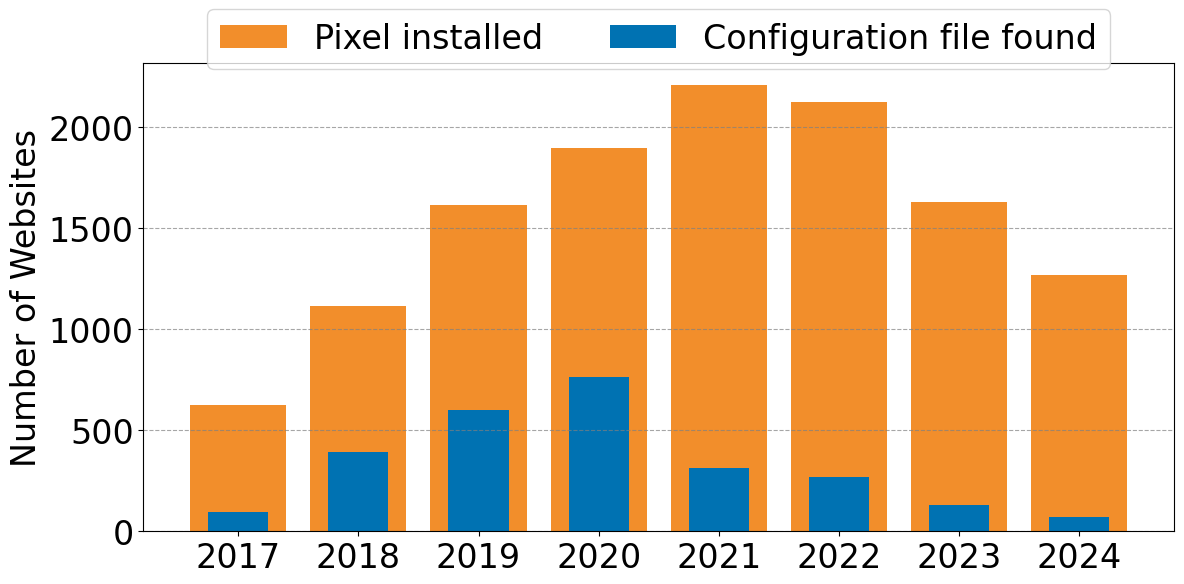

In [21]:



# Group columns by year excluding 'id' and 'website'
def group_by_year(df):
    year_columns = {}

    # Get all columns except for the first
    cols_to_process = df.columns[1:]

    # Iterate over column names
    for col in cols_to_process:
        year = col[:4]  # Extract the year part
        if year not in year_columns:
            year_columns[year] = []
        year_columns[year].append(col)

    # Combine values for each year
    result = {}
    for year, cols in year_columns.items():
        result[year] = df[cols].apply(
            lambda row: [x for val in row if isinstance(val, list) for x in val] if not row.isna().all() else None,
            axis=1
        )
    return pd.DataFrame(result)


yearly_df = group_by_year(health_pixel_presence)
final_df = pd.concat([health_pixel_presence[['website']], yearly_df], axis=1)

years = ["2024","2023","2022","2021","2020","2019","2018","2017"]
for yr in years:
    final_df[yr] = final_df[yr].apply(lambda x: x if isinstance(x, list) else [])

grouped_hospitals = (
    final_df
    .groupby('website')[years]
    .agg(lambda lists: sum(lists, []))
    .reset_index()
)
display(grouped_hospitals)

health_websites_configurations['timestamp'] = pd.to_datetime(health_websites_configurations['timestamp'])
health_websites_configurations['year'] = health_websites_configurations['timestamp'].dt.year

hospital_pixel_count = {}

for year in years:
    # config_websites = health_websites_configurations[health_websites_configurations['year']==int(year)]['website'].unique()
    pixel_websites = grouped_hospitals[grouped_hospitals[year].apply(lambda x: True if isinstance(x,list) and len(x)>0 else False)]['website'].values

    total_websites = set( list(pixel_websites))
    hospital_pixel_count[year] = len(total_websites)
    
hospital_pixel_count

health_websites_configurations['timestamp'] = pd.to_datetime(health_websites_configurations['timestamp'])
health_websites_configurations['year'] = health_websites_configurations['timestamp'].dt.year
unique_hospitals_websites_per_year = health_websites_configurations.groupby('year')['website'].nunique()
unique_hospitals_websites_per_year
# Re-import libraries after code execution environment reset
import matplotlib.pyplot as plt
import pandas as pd

# Exclude 2025
# pixel_presence = pixel_presence_count[pixel_presence_count.index < 2025]
pixel_presence = hospital_pixel_count
unique_websites_per_year = unique_hospitals_websites_per_year[unique_hospitals_websites_per_year.index < 2025]

# Align years
all_years = ["2017","2018","2019","2020","2021","2022","2023","2024"]
pixel_values = [pixel_presence.get(year, 0) for year in all_years]
all_years = list(range(2017, 2025))
unique_values = [unique_websites_per_year.get(year, 0) for year in all_years]

display(pixel_values,unique_values)

# Plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 24
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams['legend.fontsize'] = 24

fig, ax = plt.subplots()
ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)

# Main bars: total websites
ax.bar(all_years, pixel_values, color='#F28E2B', label='Pixel installed')
ax.bar(all_years, unique_values,width=0.5, color='#0072B2', label='Configuration file found')


# Overlay bars: with pixel

ax.set_ylabel('Number of Websites')
ax.set_xticks(all_years)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.tight_layout()
plt.savefig("pixel_overlay_plot_hospitals.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()


In [40]:
years = ["2024","2023","2022","2021","2020","2019","2018","2017"][::-1]
all_years = ["2024","2023","2022","2021","2020","2019","2018","2017"][::-1]

hospital_websites['timestamp'] = pd.to_datetime(hospital_websites['timestamp'])
hospital_websites['year'] = hospital_websites['timestamp'].dt.year
health_websites_configurations = hospital_websites

hospital_pixel_count = {}

for year in years:
    pixel_websites = grouped_hospitals[grouped_hospitals[year].apply(lambda x: True if isinstance(x,list) and len(x)>0 else False)]['website'].values

    total_websites = set(list(pixel_websites))
    hospital_pixel_count[year] = len(total_websites)
    
hospital_pixel_count


top10k_websites_configurations['timestamp'] = pd.to_datetime(top10k_websites_configurations['timestamp'])
top10k_websites_configurations['year'] = top10k_websites_configurations['timestamp'].dt.year

pixel_count = {}

for year in years:
    pixel_websites = grouped[grouped[year].apply(lambda x: True if isinstance(x,list) and len(x)>0 else False)]['website'].values

    total_websites = set(list(pixel_websites))
    pixel_count[year] = len(total_websites)
    
pixel_count


config_values = []

for key,value in pixel_count.items():
    config_values.append(value)

hospital_config_values = []

for key,value in hospital_pixel_count.items():
    hospital_config_values.append(value)

/tmp/ipykernel_10597/2370711039.py:19: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.8)  # Make space for top legend


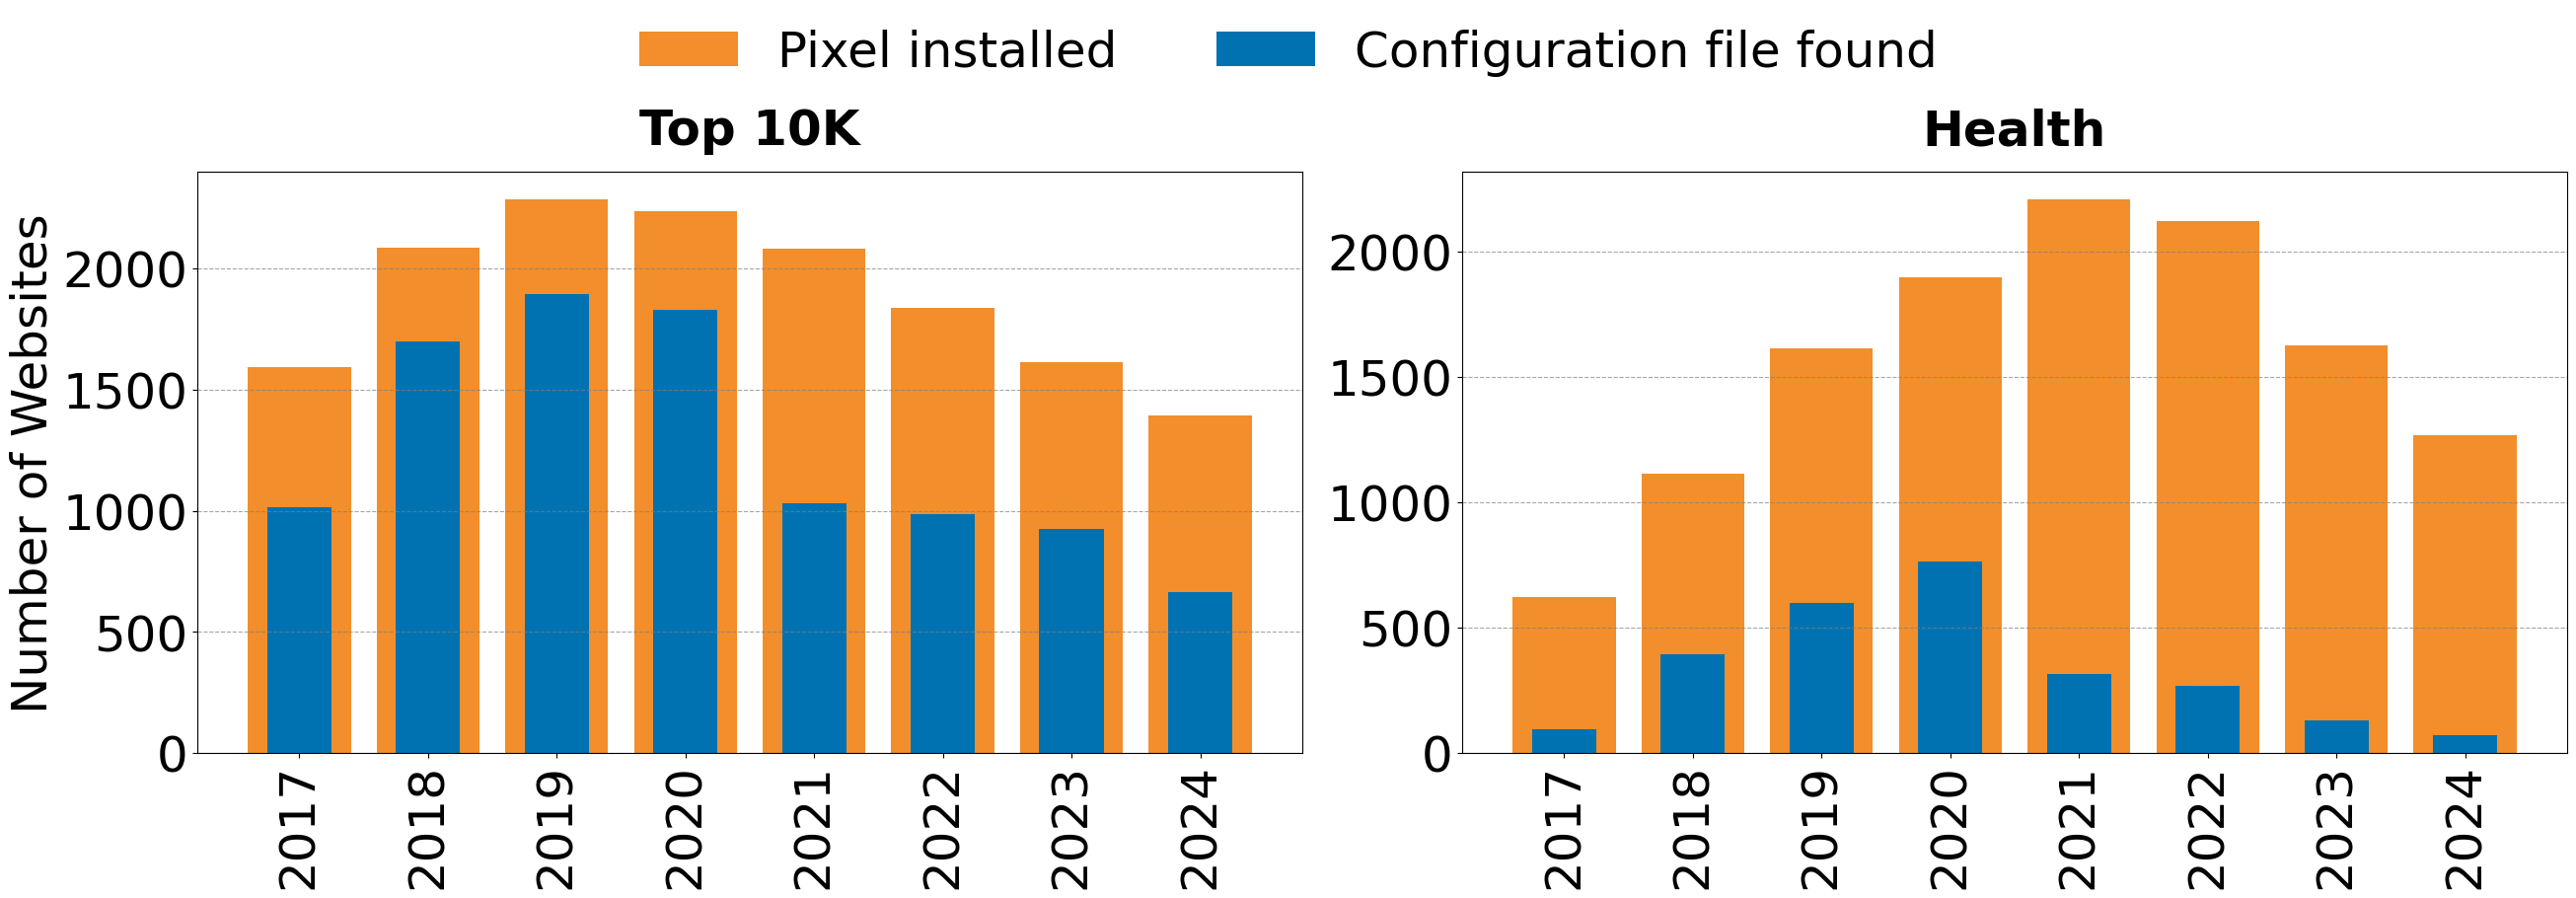

In [52]:
# Data processing code for both datasets remains unchanged

# ------------------------------------------------------------------------------------
# Plotting parameters and combined figure setup
# ------------------------------------------------------------------------------------
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 36
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['axes.titlesize'] = 36
plt.rcParams['xtick.labelsize'] = 36
plt.rcParams['ytick.labelsize'] = 36
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.constrained_layout.use'] = True


# Create combined figure with 1x2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 8))
fig.subplots_adjust(top=0.8)  # Make space for top legend

# Configure grid for both subplots
i=0
for ax in (ax1, ax2):
    
    ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)
    if i==0:
        ax.set_ylabel('Number of Websites')
        i+=1

# ------------------------------------------------------------------------------------
# First plot: Top 10K Websites
# ------------------------------------------------------------------------------------
# Use your existing data processing code here to get:
# all_years = list(range(2017, 2025))
# pixel_values = [...] (from pixel_count)
# unique_values = [...] (from unique_websites_per_year)
plt.xticks(rotation=90)
unique_websites_per_year = top10k_websites_configurations.groupby('year')['website'].nunique()
unique_websites_per_year = unique_websites_per_year[unique_websites_per_year.index < 2025]

# Plot first dataset
ax1.bar(all_years, config_values, color='#F28E2B', label='Pixel installed')
ax1.bar(all_years, unique_websites_per_year, width=0.5, color='#0072B2', label='Configuration file found')
ax1.set_xticks(all_years)
ax1.set_title('Top 10K', pad=20, weight='bold')

# ------------------------------------------------------------------------------------
# Second plot: Hospitals
# ------------------------------------------------------------------------------------
# Use your existing hospital data processing code here to get:
# all_years = list(range(2017, 2025))
# pixel_values_h = [...] (from hospital_pixel_count)
# unique_values_h = [...] (from unique_hospitals_websites_per_year)
unique_hospitals_websites_per_year = health_websites_configurations.groupby('year')['website'].nunique()
unique_websites_per_year = unique_hospitals_websites_per_year[unique_hospitals_websites_per_year.index < 2025]


# Plot second dataset
ax2.bar(all_years, hospital_config_values, color='#F28E2B')
ax2.bar(all_years, unique_websites_per_year, width=0.5, color='#0072B2')
ax2.set_xticks(all_years)
ax2.set_title('Health', pad=20, weight='bold')
ax1.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='x', rotation=90)
# ------------------------------------------------------------------------------------
# Create unified legend
# ------------------------------------------------------------------------------------
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, 
           loc='upper center', 
           ncol=2,
           bbox_to_anchor=(0.5, 1.15),
           frameon=False)

# ------------------------------------------------------------------------------------
# Final output
# ------------------------------------------------------------------------------------
plt.savefig("combined_pixel_analysis.pdf", 
            format="pdf", 
            bbox_inches="tight", 
            dpi=600)
plt.show()